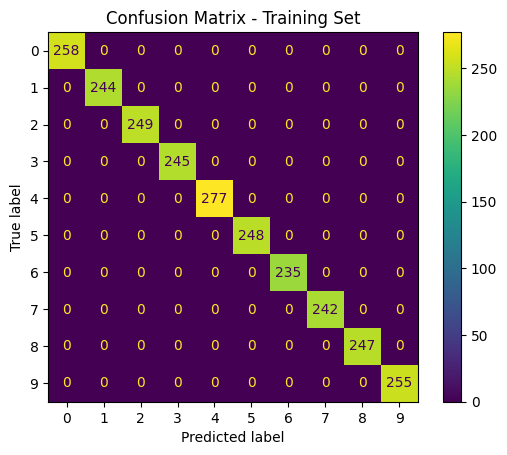

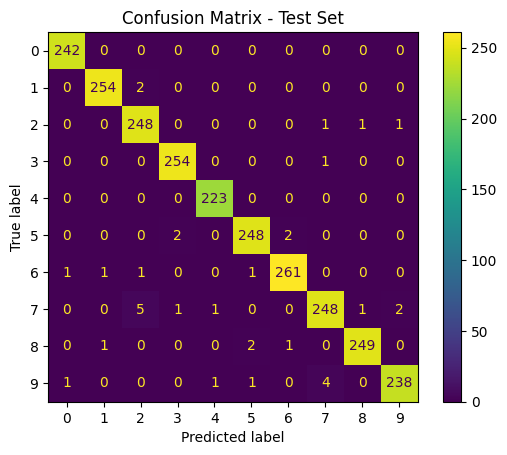

Accuracy for the test set: 98.60%


In [1]:
import cv2
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Constants:
SIZE_IMAGE = 20
NUMBER_CLASSES = 10

def load_digits_and_labels(big_image):
    """ Returns all the digits from the 'big' image and creates the corresponding labels for each image"""
    # Load the 'big' image containing all the digits:
    digits_img = cv2.imread(big_image, 0)
    # Get all the digit images from the 'big' image:
    number_rows = digits_img.shape[1] / SIZE_IMAGE
    rows = np.vsplit(digits_img, digits_img.shape[0] / SIZE_IMAGE)

    digits = []
    for row in rows:
        row_cells = np.hsplit(row, number_rows)
        for digit in row_cells:
            digits.append(digit)
    digits = np.array(digits)

    # Create the labels for each image:
    labels = np.repeat(np.arange(NUMBER_CLASSES), len(digits) / NUMBER_CLASSES)
    return digits, labels

def deskew(img):
    """Pre-processing of the images"""
    m = cv2.moments(img)
    if abs(m['mu02']) < 1e-2:
        return img.copy()
    skew = m['mu11'] / m['mu02']
    M = np.float32([[1, skew, -0.5 * SIZE_IMAGE * skew], [0, 1, 0]])
    img = cv2.warpAffine(img, M, (SIZE_IMAGE, SIZE_IMAGE), flags=cv2.WARP_INVERSE_MAP | cv2.INTER_LINEAR)
    return img

def svm_init(C=12.5, gamma=0.50625):
    """Creates empty model and assigns main parameters"""
    model = cv2.ml.SVM_create()
    model.setGamma(gamma)
    model.setC(C)
    model.setKernel(cv2.ml.SVM_RBF)
    model.setType(cv2.ml.SVM_C_SVC)
    model.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6))
    return model

def svm_train(model, samples, responses):
    """Trains the model using the samples and the responses"""
    model.train(samples, cv2.ml.ROW_SAMPLE, responses)
    return model

def svm_predict(model, samples):
    """Predicts the response based on the trained model"""
    return model.predict(samples)[1].ravel()

def get_hog():
    """Get HoG descriptor"""
    hog = cv2.HOGDescriptor((SIZE_IMAGE, SIZE_IMAGE), (8, 8), (4, 4), (8, 8), 9, 1, -1, 0, 0.2, 1, 64, True)
    return hog

# Load all the digits and the corresponding labels:
digits, labels = load_digits_and_labels(r'C:\Users\Rebeca MG\Laboratorios_VA\img\digits.png')

# Shuffle data
rand = np.random.RandomState(1234)
shuffle = rand.permutation(len(digits))
digits, labels = digits[shuffle], labels[shuffle]

# HoG feature descriptor:
hog = get_hog()

# Compute the descriptors for all the images:
hog_descriptors = []
for img in digits:
    hog_descriptors.append(hog.compute(deskew(img)))
hog_descriptors = np.squeeze(hog_descriptors)

# Split the data into training and testing (50% for each one):
partition = int(0.5 * len(hog_descriptors))
hog_descriptors_train, hog_descriptors_test = np.split(hog_descriptors, [partition])
labels_train, labels_test = np.split(labels, [partition])

# Train the SVM model with RBF kernel
model = svm_init(C=12.5, gamma=0.50625)
svm_train(model, hog_descriptors_train, labels_train)

# Predictions for both train and test sets
predictions_train = svm_predict(model, hog_descriptors_train)
predictions_test = svm_predict(model, hog_descriptors_test)

# Generate confusion matrix for train set
cm_train = confusion_matrix(labels_train, predictions_train)
disp_train = ConfusionMatrixDisplay.from_predictions(labels_train, predictions_train)
plt.title("Confusion Matrix - Training Set")
plt.show()

# Generate confusion matrix for test set
cm_test = confusion_matrix(labels_test, predictions_test)
disp_test = ConfusionMatrixDisplay.from_predictions(labels_test, predictions_test)
plt.title("Confusion Matrix - Test Set")
plt.show()

# Report accuracy for the test set
accuracy = accuracy_score(labels_test, predictions_test)
print(f'Accuracy for the test set: {accuracy * 100:.2f}%')

In [1]:
import cv2
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

# Constants
SIZE_IMAGE = 20
NUMBER_CLASSES = 10

def load_digits_and_labels(big_image_path):
    """ Load all digits and create labels from the big image. """
    digits_img = cv2.imread(big_image_path, 0)
    number_rows = digits_img.shape[1] // SIZE_IMAGE
    rows = np.vsplit(digits_img, digits_img.shape[0] // SIZE_IMAGE)

    digits = []
    for row in rows:
        row_cells = np.hsplit(row, number_rows)
        for digit in row_cells:
            digits.append(digit)
    digits = np.array(digits)

    labels = np.repeat(np.arange(NUMBER_CLASSES), len(digits) / NUMBER_CLASSES)
    return digits, labels

def deskew(img):
    """ Apply deskewing to the image. """
    m = cv2.moments(img)
    if abs(m['mu02']) < 1e-2:
        return img.copy()
    skew = m['mu11'] / m['mu02']
    M = np.float32([[1, skew, -0.5 * SIZE_IMAGE * skew], [0, 1, 0]])
    img = cv2.warpAffine(img, M, (SIZE_IMAGE, SIZE_IMAGE), flags=cv2.WARP_INVERSE_MAP | cv2.INTER_LINEAR)
    return img

def get_hog():
    """ Define HOG descriptor. """
    return cv2.HOGDescriptor((SIZE_IMAGE, SIZE_IMAGE), (8, 8), (4, 4), (8, 8), 9, 1, -1, 0, 0.2, 1, 64, True)

# Load digits and labels
digits, labels = load_digits_and_labels(r'C:\Users\Rebeca MG\Laboratorios_VA\img\digits.png')

# Shuffle data
rand = np.random.RandomState(1234)
shuffle = rand.permutation(len(digits))
digits, labels = digits[shuffle], labels[shuffle]

# Calculate HOG descriptors for each image
hog = get_hog()
hog_descriptors = np.array([hog.compute(deskew(img)).ravel() for img in digits])

# Perform 25-fold cross-validation
kf = KFold(n_splits=25, shuffle=True, random_state=1234)
accuracies = []

for train_index, test_index in kf.split(hog_descriptors):
    # Split data into training and testing sets
    hog_descriptors_train, hog_descriptors_test = hog_descriptors[train_index], hog_descriptors[test_index]
    labels_train, labels_test = labels[train_index], labels[test_index]

    # Train SVM model
    model = SVC(C=12.5, gamma=0.50625, kernel='rbf')
    model.fit(hog_descriptors_train, labels_train)

    # Test model
    predictions = model.predict(hog_descriptors_test)
    accuracy = accuracy_score(labels_test, predictions)
    accuracies.append(accuracy)

# Calculate average accuracy over 25 folds
average_accuracy = np.mean(accuracies)
print(f'Average accuracy over 25 folds: {average_accuracy * 100:.2f}%')


Average accuracy over 25 folds: 98.48%


# III PARTE

## Entrenamieto usando SVM Y HOG SKLEARN

### Carga de los datasets de validation y train

In [6]:
import os
import cv2
import numpy as np

#Definición de los directorios del dataset
base_dir = r'C:\Users\Rebeca MG\Laboratorios_VA\petsDataset'
validation_dir = os.path.join(base_dir, 'validation')
train_dir = os.path.join(base_dir, 'train')

# Directorio con las imagenes de validation
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
validation_parrots_dir = os.path.join(validation_dir, 'parrots')

# Directorio con las imagenes de train
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
train_parrots_dir = os.path.join(train_dir, 'parrots')

# Lista de Nombres de Archivos de Validation
validation_cat_fnames = os.listdir(validation_cats_dir )
validation_dog_fnames = os.listdir( validation_dogs_dir )
validation_parrot_fnames = os.listdir( validation_parrots_dir )

# Lista de Nombres de Archivos de train
train_cat_fnames = os.listdir( train_cats_dir )
train_dog_fnames = os.listdir( train_dogs_dir )
train_parrot_fnames = os.listdir( train_parrots_dir )

# Lista de Rutas de archivos de validation
validation_cat_fnames = list(map(lambda x: os.path.join(validation_cats_dir, x) , validation_cat_fnames)) 
validation_dog_fnames = list(map(lambda x: os.path.join(validation_dogs_dir, x) , validation_dog_fnames)) 
validation_parrot_fnames = list(map(lambda x: os.path.join(validation_parrots_dir, x) , validation_parrot_fnames)) 


# Lista de Rutas de archivos de train
train_cat_fnames = list(map(lambda x: os.path.join(train_cats_dir, x) , train_cat_fnames))
train_dog_fnames = list(map(lambda x: os.path.join(train_dogs_dir, x) , train_dog_fnames))
train_parrot_fnames = list(map(lambda x: os.path.join(train_parrots_dir, x) , train_parrot_fnames))


# Lista con todas las paths de archivos de validation
validation_fnames = validation_cat_fnames + validation_dog_fnames + validation_parrot_fnames

# Lista con todas las paths de archivos de train
train_fnames = train_cat_fnames + train_dog_fnames + train_parrot_fnames


# Prepara las etiquetas de cada instancia de validation
validation_labels =[ 0 for _ in validation_cat_fnames ]
validation_labels.extend([ 1 for _ in validation_dog_fnames ])
validation_labels.extend([ 2 for _ in validation_parrot_fnames ])


# Prepara las etiquetas de cada instancia de train
train_labels =[ 0 for _ in train_cat_fnames ]
train_labels.extend([ 1 for _ in train_dog_fnames ])
train_labels.extend([ 2 for _ in train_parrot_fnames ])

### Funciones para generar la matriz de confusión del modelo

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def generarMC(model, X, y, categorias, normal=None ):
    fig=ConfusionMatrixDisplay.from_estimator(model, X, y, display_labels=categorias, cmap="Greens", normalize=normal)  
    fig.figure_.suptitle("Confusion Matrix")
    plt.show()
    
def generarMCPredictions(y_real, y_pred, categorias ):
    fig=ConfusionMatrixDisplay.from_estimator(y_real, y_pred, display_labels=categorias, cmap="Greens")  
    fig.figure_.suptitle("Confusion Matrix")
    plt.show()

### Extración de descriptores HOG

In [8]:
def get_hog(list_fnames):
    # Definir Resolucion de las imagenes a usar
    img_size =(380,380)

    # Definir los parámetros del descriptor HOG
    win_size = img_size     # Tamaño de la ventana de detección
    block_size = (40, 40)   # Tamaño del bloque
    block_stride = (20, 20) # Desplazamiento del bloque
    cell_size = (20, 20)    # Tamaño de la celda
    nbins = 9               # Número de bins del histograma

    # Crear un descriptor HOG con parámetros personalizados
    hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, nbins)

    hog_descriptor_set = []
    for imgs in list_fnames:
        # Cargar la imagen 
        orgimage = cv2.imread(  imgs  )
        image = cv2.resize(orgimage, img_size)

        # Convertir la imagen a escala de grises 
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
        # Calcular los descriptores HOG de la imagen en escala de grises
        hog_descriptors = hog.compute(gray_image)
        hog_descriptor_set.append(hog_descriptors)
    
    # Remover los ejes/dimensiones de longitud 1 de la lista
    hog_descriptor_set = np.squeeze(hog_descriptor_set) 
    return hog_descriptor_set

### Obteción de los descriptores HOG para las secuencias de Validation y Test

In [9]:
validation_hog = get_hog(validation_fnames)
train_hog = get_hog(train_fnames)

### Usando Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

#Definición del Modelo 
clfRF = RandomForestClassifier(n_jobs=6, 
                               random_state=0, 
                               n_estimators=1000,
                               )
#fit/validation -> Se hace el entrenamiendo del modelo
clfRF.fit(validation_hog, np.array(validation_labels))

RandomForestClassifier(n_estimators=1000, n_jobs=6, random_state=0)

In [11]:
# Precisión lograda por el clasificador
print(f'{clfRF.score(validation_hog, np.array(validation_labels)):.2%}')

100.00%


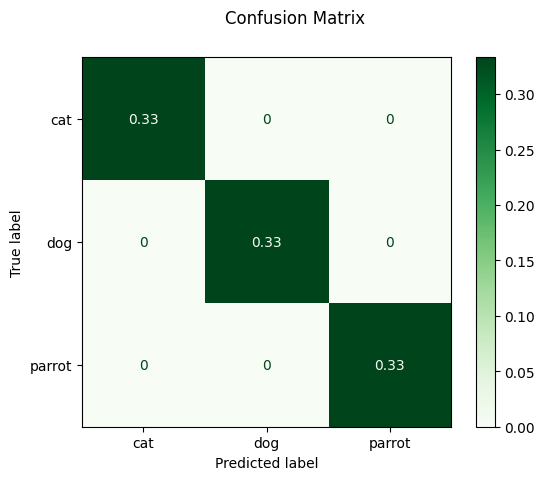

In [12]:
# Matriz de confusión normalizada de validation
generarMC(clfRF, validation_hog, validation_labels, ['cat', 'dog','parrot'], 'all')

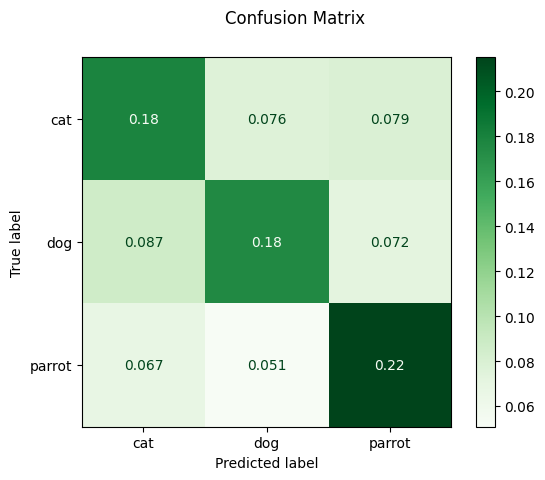

In [13]:
# Matriz de confusión normalizada de test
generarMC(clfRF, train_hog, train_labels, ['cat', 'dog','parrot'], 'all')

In [15]:
def clasificar(path):
    global clfRF
    hogDesc = get_hog([path])
    labels = ['cat', 'dog','parrot']
    res = clfRF.predict(hogDesc.reshape(1, -1))
    resProb = clfRF.predict_proba(hogDesc.reshape(1, -1))
    labelResultado = f'En la imagen aparece un {labels[res[0]]}, con una probalidad de { resProb[0,res[0]]:.2%}' 
    return labelResultado

In [16]:
import gradio as gr

gr.Interface(
    fn = clasificar,    # funcion 
    inputs = gr.Image(type="filepath"), # tipo de entrada
    outputs = "textbox"  
).launch()

C:\Users\Rebeca MG\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860


RemoteProtocolError: Server disconnected without sending a response.

# IV PARTE

## Reconocimiento de dígitos escritos a mano mediante las funciones MLP y HoG de SKLearn

In [23]:
# At this point we split the data into training and testing (70% for training):
hog_descriptors_train, hog_descriptors_test, labels_train, labels_test = train_test_split(hog_descriptors,labels,random_state=1, test_size=0.3)

NameError: name 'train_test_split' is not defined

In [35]:
print('Training MLP model ...')

clf = MLPClassifier(hidden_layer_sizes=(256,128,64,32),activation="relu",random_state=25)
clf.fit(hog_descriptors_train, labels_train)

Training MLP model ...


NameError: name 'MLPClassifier' is not defined

In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Primera modificación: Cambiamos el tamaño de las capas ocultas y agregamos una capa adicional.
print('Training MLP model with Modification 1...')

# Configuración del modelo modificado
clf1 = MLPClassifier(hidden_layer_sizes=(300, 150, 75, 50, 25), activation="relu", random_state=25, max_iter=300)
clf1.fit(hog_descriptors_train, labels_train)

# Predicciones y evaluación para el conjunto de entrenamiento
predictions_train1 = clf1.predict(hog_descriptors_train)
accuracy_train1 = accuracy_score(labels_train, predictions_train1)
cm_train1 = confusion_matrix(labels_train, predictions_train1)
ConfusionMatrixDisplay(cm_train1).plot()
plt.title("Confusion Matrix - Train Set (Modification 1)")
plt.show()

# Predicciones y evaluación para el conjunto de prueba
predictions_test1 = clf1.predict(hog_descriptors_test)
accuracy_test1 = accuracy_score(labels_test, predictions_test1)
cm_test1 = confusion_matrix(labels_test, predictions_test1)
ConfusionMatrixDisplay(cm_test1).plot()
plt.title("Confusion Matrix - Test Set (Modification 1)")
plt.show()

print(f'Modification 1 - Hidden layers: (300, 150, 75, 50, 25)')
print(f'Accuracy on Train Set: {accuracy_train1 * 100:.2f}%')
print(f'Accuracy on Test Set: {accuracy_test1 * 100:.2f}%\n')

# Segunda modificación: Reducimos la cantidad de capas y aumentamos el tamaño de la primera capa.
print('Training MLP model with Modification 2...')

# Configuración del modelo modificado
clf2 = MLPClassifier(hidden_layer_sizes=(512, 256, 128), activation="relu", random_state=25, max_iter=300)
clf2.fit(hog_descriptors_train, labels_train)

# Predicciones y evaluación para el conjunto de entrenamiento
predictions_train2 = clf2.predict(hog_descriptors_train)
accuracy_train2 = accuracy_score(labels_train, predictions_train2)
cm_train2 = confusion_matrix(labels_train, predictions_train2)
ConfusionMatrixDisplay(cm_train2).plot()
plt.title("Confusion Matrix - Train Set (Modification 2)")
plt.show()

# Predicciones y evaluación para el conjunto de prueba
predictions_test2 = clf2.predict(hog_descriptors_test)
accuracy_test2 = accuracy_score(labels_test, predictions_test2)
cm_test2 = confusion_matrix(labels_test, predictions_test2)
ConfusionMatrixDisplay(cm_test2).plot()
plt.title("Confusion Matrix - Test Set (Modification 2)")
plt.show()

print(f'Modification 2 - Hidden layers: (512, 256, 128)')
print(f'Accuracy on Train Set: {accuracy_train2 * 100:.2f}%')
print(f'Accuracy on Test Set: {accuracy_test2 * 100:.2f}%')


Training MLP model with Modification 1...


NameError: name 'hog_descriptors_train' is not defined

98.83%


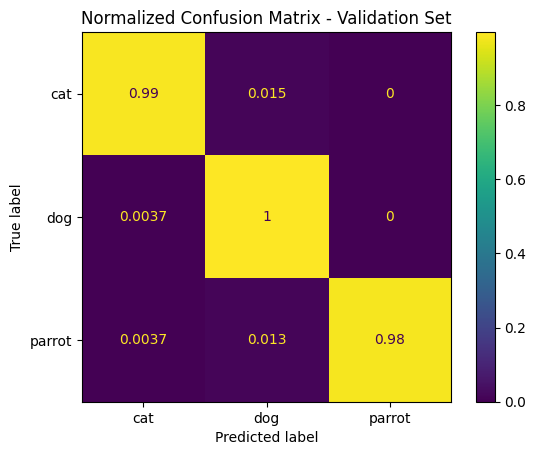

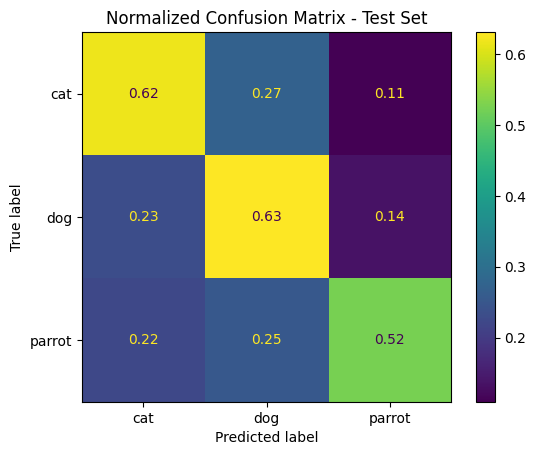

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Definición del modelo MLP (con arquitectura ejemplo, puedes ajustar los parámetros)
clfMLP = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation="relu", random_state=0, max_iter=300)
clfMLP.fit(validation_hog, np.array(validation_labels))

# Precisión lograda por el clasificador MLP en el conjunto de validación
print(f'{clfMLP.score(validation_hog, np.array(validation_labels)):.2%}')

# Función para generar y mostrar la matriz de confusión
def generarMC(model, X, y, labels, title):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='viridis')
    plt.title(f'Normalized Confusion Matrix - {title} Set')
    plt.show()

# Matriz de confusión normalizada de validación
generarMC(clfMLP, validation_hog, validation_labels, ['cat', 'dog', 'parrot'], 'Validation')

# Matriz de confusión normalizada de prueba
generarMC(clfMLP, test_hog, test_labels, ['cat', 'dog', 'parrot'], 'Test')

In [30]:
def clasificar(path):
    global clfMLP
    hogDesc = get_hog([path])
    labels = ['cat', 'dog', 'parrot']
    res = clfMLP.predict(hogDesc.reshape(1, -1))
    resProb = clfMLP.predict_proba(hogDesc.reshape(1, -1))
    labelResultado = f'En la imagen aparece un {labels[res[0]]}, con una probabilidad de {resProb[0, res[0]]:.2%}'
    return labelResultado

In [31]:
import gradio as gr
gr.Interface(
    fn=clasificar,       # función de clasificación
    inputs=gr.Image(type="filepath"),  # tipo de entrada
    outputs="textbox"  # tipo de salida
).launch()

* Running on local URL:  http://127.0.0.1:7861


RemoteProtocolError: Server disconnected without sending a response.